In [34]:
from one.api import ONE
from pathlib import Path
import yaml
import os
import wfield
import numpy as np
import matplotlib.patches as mpatches
import pandas as pd
from prior_localization.prepare_data import prepare_widefield
from brainbox.io.one import SessionLoader
from brainwidemap.bwm_loading import load_trials_and_mask
from prior_localization.functions.utils import compute_mask
from ibl_info.prepare_data_pid import get_new_cinc_intervals
import seaborn as sns
from matplotlib import pyplot as plt
import pickle as pkl
from tqdm import tqdm
from glob import glob
import re
from scipy.stats import wilcoxon

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
def mean_accuracies_for_wifi(files):

    # we drop 'ff7a70f5-a2b6-4e7e-938e-e7208e0678c2'
    weird_eid = "b83033ed-c5d0-4e49-a595-0a04c48f059d"
    with open(files[0], "rb") as f:
        d = pkl.load(f)
    frames = list(d.keys())
    pairs = list(d[frames[0]].keys())
    regions = [re.findall(r"\['(.*?)'\]", p) for p in pairs]
    mean_accuracies = np.zeros((len(files), len(regions), 3, 2))

    for file_idx in range(len(files)):

        eid_found = files[file_idx].find(weird_eid)
        # if eid_found != -1:
        #     print(f"{files[file_idx]}")
        #     continue

        with open(files[file_idx], "rb") as f:
            d = pkl.load(f)

        frames = list(d.keys())
        pairs = list(d[frames[0]].keys())
        regions = [re.findall(r"\['(.*?)'\]", p) for p in pairs]
        for f_idx, frame in enumerate(frames):
            for k_idx, k in enumerate(d[frame].keys()):
                results = d[frame][k]["results"]
                mean_a = []
                mean_b = []
                for idx in range(len(results)):
                    mean_a.append(results[idx]["balanced_acc_A"])
                    mean_b.append(results[idx]["balanced_acc_B"])
                mean_accuracies[file_idx, k_idx, f_idx, 0] = np.mean(mean_a)
                mean_accuracies[file_idx, k_idx, f_idx, 1] = np.mean(mean_b)
                if np.mean(mean_a) == 0:
                    print(f"{frame}, {k}, {files[file_idx]}")
    return mean_accuracies


def null_accuracies_for_wifi(files):

    with open(files[0], "rb") as f:
        d = pkl.load(f)
    frames = list(d.keys())
    pairs = list(d[frames[0]].keys())
    regions = [re.findall(r"\['(.*?)'\]", p) for p in pairs]
    null_means = np.zeros((len(files), len(regions), 3, 2))
    null_stds = np.zeros((len(files), len(regions), 3, 2))

    for file_idx in range(len(files)):

        with open(files[file_idx], "rb") as f:
            d = pkl.load(f)
        frames = list(d.keys())
        pairs = list(d[frames[0]].keys())
        regions = [re.findall(r"\['(.*?)'\]", p) for p in pairs]
        for f_idx, frame in enumerate(frames):
            for k_idx, k in enumerate(d[frame].keys()):
                mean_a = d[frame][k]["acc_A"]
                mean_b = d[frame][k]["acc_B"]
                null_means[file_idx, k_idx, f_idx, 0] = np.mean(mean_a)
                null_means[file_idx, k_idx, f_idx, 1] = np.mean(mean_b)
                null_stds[file_idx, k_idx, f_idx, 0] = np.std(mean_a)
                null_stds[file_idx, k_idx, f_idx, 1] = np.std(mean_b)
                if np.mean(mean_a) == 0:
                    print(f"{frame}, {k}, {files[file_idx]}")
    return null_means, null_stds

In [114]:
# files_stim = np.sort(glob("../data/generated/wfi_decoders/stim/equi_3/*.pkl"))
# files_stim_null = np.sort(glob("../data/generated/wfi_decoders/stim/null/*.pkl"))
# files_choice_null = np.sort(glob("../data/generated/wfi_decoders/choice/null/*.pkl"))

files_choice = np.sort(glob("../data/generated/wfi_decoders/choice/subsampled/*.pkl"))
files_choice_acc = np.sort(glob("../data/generated/wfi_decoders/choice/equi_3/*.pkl"))
files_stim = np.sort(
    glob("../data/generated/significant_pid_decoders/stim_decoder_only/hyperopt/*.pkl")
)

In [ ]:
eid_lists = []
for idx in range(len(files_choice)):
    eid = files_choice[idx].rsplit("/")[-1].rsplit("_wfi")[0]
    eid_lists.append(eid)

eid_lists_null = []
for idx in range(len(files_choice_null)):
    eid = files_choice_null[idx].rsplit("/")[-1].rsplit("_wfi")[0]
    eid_lists_null.append(eid)

In [ ]:
list(set(eid_lists) - set(eid_lists_null))

[]

In [61]:
mean_accuracies_stim = mean_accuracies_for_wifi(files_stim)
null_mean_stim, null_std_stim = null_accuracies_for_wifi(files_stim_null)

In [62]:
mean_accuracies_stim.shape, null_mean_stim.shape

((48, 15, 3, 2), (48, 15, 3, 2))

In [171]:
with open(files_choice[0], "rb") as f:
    d = pkl.load(f)
frames = list(d.keys())
pairs = list(d[frames[0]].keys())
regions = [re.findall(r"\['(.*?)'\]", p) for p in pairs]

In [64]:
def compute_delta_array(real_values, null_values):
    # calculate deltas
    delta_arrays = np.zeros((real_values.shape[0], real_values.shape[1], real_values.shape[-1]))
    for region_pair_idx in range(real_values.shape[1]):
        # we only look at the last frame
        # each pair though
        for idx in range(2):
            delta_arrays[:, region_pair_idx, idx] = (
                real_values[:, region_pair_idx, 2, idx] - null_values[:, region_pair_idx, 2, idx]
            )
    return delta_arrays

In [65]:
def compute_significances(delta_arrays):
    for r in range(delta_arrays.shape[1]):
        d = delta_arrays[:, r, 0]
        stat, p = wilcoxon(d)
        print(f"Region {r}: median Δ={np.median(d):.3f}, p={p:.3g}")
    for r in range(delta_arrays.shape[1]):
        d = delta_arrays[:, r, 1]
        stat, p = wilcoxon(d)
        print(f"Region {r}: median Δ={np.median(d):.3f}, p={p:.3g}")

In [79]:
def plot_real_null(delta_A, delta_B, region_pairs, color_a, color_b):

    n_animals, n_regions = delta_A.shape

    offset = 0.25
    width = 0.35

    fig, ax = plt.subplots(figsize=(1.4 * n_regions, 5))

    for r in range(n_regions):
        # positions
        pos_A = r - offset
        pos_B = r + offset

        # boxplots
        ax.boxplot(
            delta_A[:, r],
            positions=[pos_A],
            widths=width,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(alpha=0.4),
            medianprops=dict(linewidth=2),
        )

        ax.boxplot(
            delta_B[:, r],
            positions=[pos_B],
            widths=width,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(alpha=0.4),
            medianprops=dict(linewidth=2),
        )

        # stripplots (jittered animals)
        jitter = 0.04
        ax.scatter(
            pos_A + jitter * np.random.randn(n_animals),
            delta_A[:, r],
            alpha=0.8,  # , color=color_a[r]
        )

        ax.scatter(
            pos_B + jitter * np.random.randn(n_animals),
            delta_B[:, r],
            alpha=0.8,  # , color=color_b[r]
        )

    # null line
    ax.axhline(0, linestyle="--", color="black", linewidth=1)

    # ticks and labels
    ax.set_xticks(range(n_regions), region_pairs)
    ax.set_ylabel("Real - Null decoding accuracy")
    ax.set_ylim(-0.1, 0.25)
    plt.tight_layout()
    plt.show()

In [80]:
delta_array_stim = compute_delta_array(mean_accuracies_stim, null_mean_stim)

In [81]:
colors = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
]
color_a = [
    colors[0],
    colors[0],
    colors[0],
    colors[0],
    colors[1],
    colors[1],
    colors[1],
    colors[2],
    colors[2],
    colors[3],
]
color_b = [
    colors[1],
    colors[2],
    colors[3],
    colors[4],
    colors[2],
    colors[3],
    colors[4],
    colors[3],
    colors[4],
    colors[4],
]

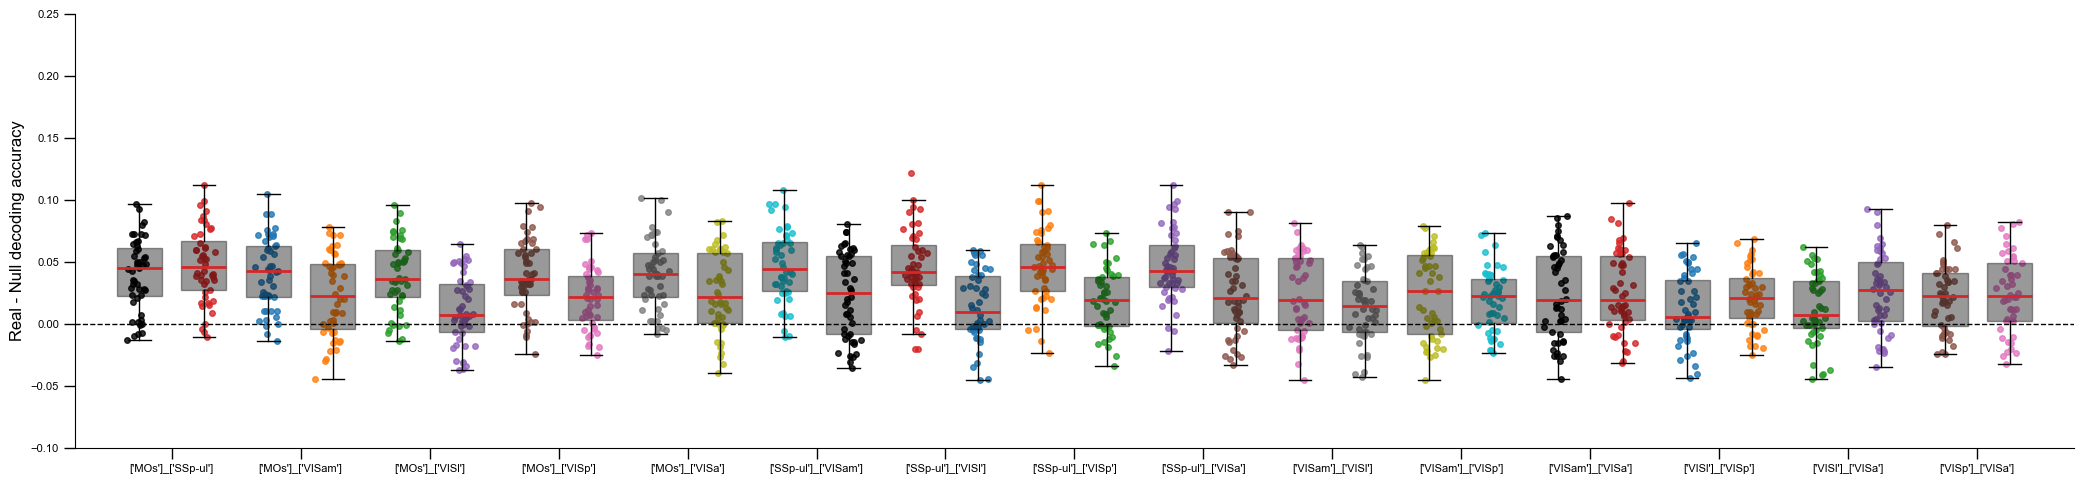

In [83]:
plot_real_null(
    delta_array_stim[:, :, 0], delta_array_stim[:, :, 1], pairs, color_a=color_a, color_b=color_b
)

In [74]:
mean_accuracies_choice = mean_accuracies_for_wifi(files_choice)
null_mean_choice, null_std_choice = null_accuracies_for_wifi(files_choice_null)

In [75]:
delta_array_choice = compute_delta_array(mean_accuracies_choice, null_mean_choice)

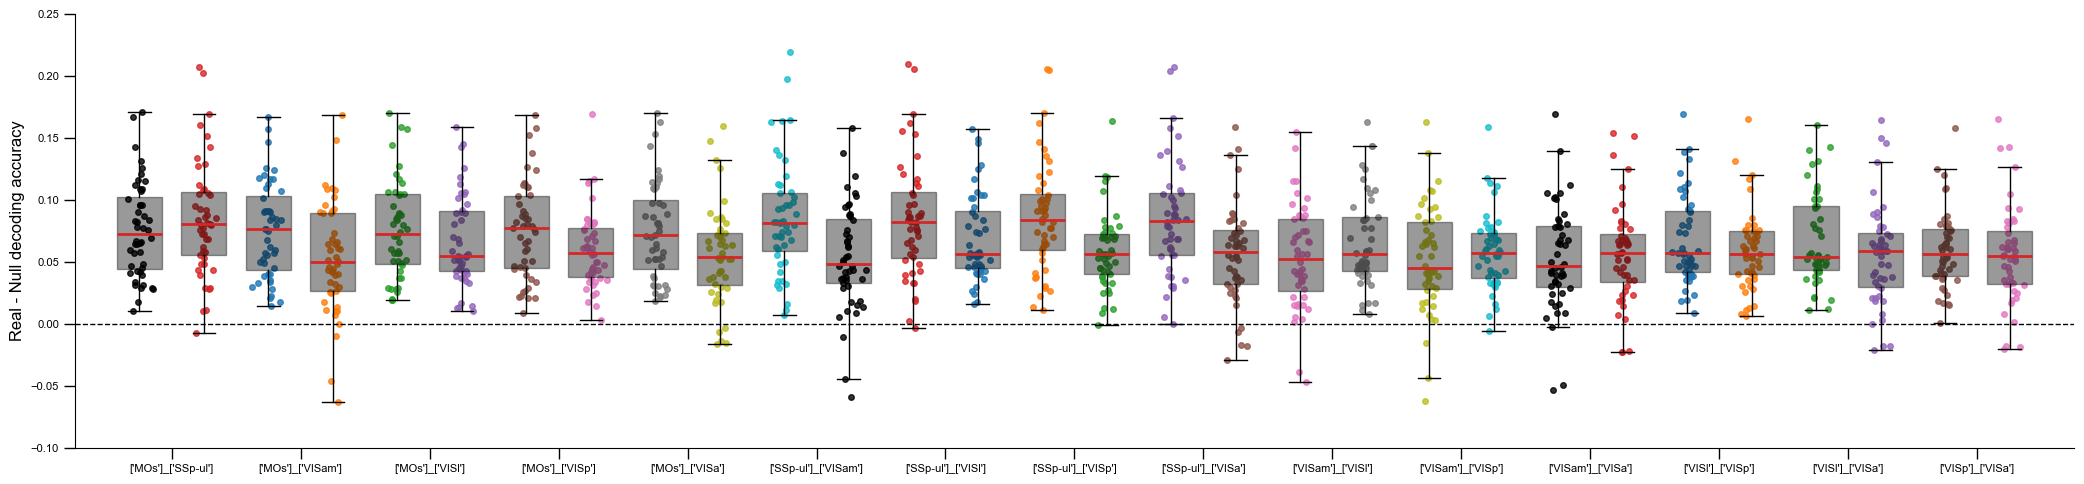

In [84]:
plot_real_null(
    delta_array_choice[:, :, 0],
    delta_array_choice[:, :, 1],
    pairs,
    color_a=color_a,
    color_b=color_b,
)

In [85]:
# okay, now plot RSI's

In [86]:
d[2]["['MOs']_['SSp-ul']"]["information_results"].shape

(50, 3, 7)

In [ ]:
# con, incon

# congegrate:

In [87]:
def collapse_region(region_data, only_positive=False):
    # the 7 is mia, mib, tvmi, unqa, unqb, red, syn
    if only_positive:
        arg_idx = region_data["information_results"][:, 0, 2] >= 0
    else:
        arg_idx = np.ones_like(region_data["information_results"][:, 2, 2], dtype=np.bool)
    rsi_congruent = np.nanmean(
        region_data["information_results"][:, 0, 2][arg_idx]
        - (
            region_data["information_results"][:, 0, 0][arg_idx]
            + region_data["information_results"][:, 0, 1][arg_idx]
        ),
        axis=0,
    )
    if only_positive:
        arg_idx = region_data["information_results"][:, 1, 2] >= 0
    else:
        arg_idx = np.ones_like(region_data["information_results"][:, 2, 2], dtype=np.bool)
    rsi_incongruent = np.nanmean(
        region_data["information_results"][:, 1, 2][arg_idx]
        - (
            region_data["information_results"][:, 1, 0][arg_idx]
            + region_data["information_results"][:, 1, 1][arg_idx]
        ),
        axis=0,
    )
    if only_positive:
        arg_idx = region_data["information_results"][:, 2, 2] >= 0
    else:
        arg_idx = np.ones_like(region_data["information_results"][:, 2, 2], dtype=np.bool)
    rsi_all = np.nanmean(
        region_data["information_results"][:, 2, 2][arg_idx]
        - (
            region_data["information_results"][:, 2, 0][arg_idx]
            + region_data["information_results"][:, 2, 1][arg_idx]
        ),
        axis=0,
    )

    return rsi_congruent, rsi_incongruent, rsi_all

In [88]:
def pids_per_animal(animal, frame_idx, only_positive=False):
    rsi_congruent_array = []
    rsi_incongruent_array = []
    rsi_all_array = []

    for region_name in animal[frame_idx].keys():
        rsi_congruent, rsi_incongruent, rsi_all = collapse_region(
            animal[frame_idx][region_name], only_positive=only_positive
        )
        rsi_congruent_array.append(rsi_congruent)
        rsi_incongruent_array.append(rsi_incongruent)
        rsi_all_array.append(rsi_all)

    return (
        np.asarray(rsi_congruent_array),
        np.asarray(rsi_incongruent_array),
        np.asarray(rsi_all_array),
    )

In [89]:
def congregate_data(files, frame_idx, only_positive):

    rsi_congruent = []
    rsi_incongruent = []
    rsi_all = []
    for filename in files:
        with open(filename, "rb") as f:
            animal = pkl.load(f)

        if animal == {}:
            continue

        # now for one animal
        (
            rsi_congruent_values,
            rsi_incongruent_values,
            rsi_all_values,
        ) = pids_per_animal(animal, frame_idx, only_positive)

        # now what?
        # append for all animals

        rsi_congruent.append(rsi_congruent_values)
        rsi_incongruent.append(rsi_incongruent_values)
        rsi_all.append(rsi_all_values)
    return np.asarray(rsi_congruent), np.asarray(rsi_incongruent), np.asarray(rsi_all)

In [108]:
rsi_c_anima_stim, rsi_inc_anima_stim, rsi_all_anima_stim = congregate_data(files_stim, 2, False)
rsi_c_anima_choice, rsi_inc_anima_choice, rsi_all_anima_choice = congregate_data(
    files_choice, 2, False
)

In [172]:
names = [f"{r[0]}_{r[1]}" for r in regions]

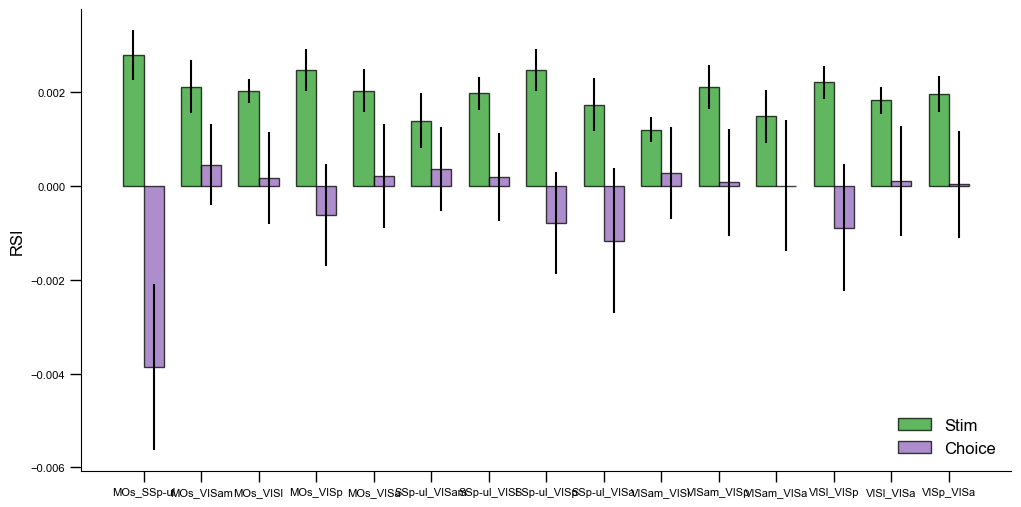

In [106]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    np.arange(rsi_all_anima_stim.shape[1]) - 0.35 / 2,
    np.mean(rsi_all_anima_stim, axis=0),
    yerr=np.std(rsi_all_anima_stim, axis=0) / np.sqrt(rsi_all_anima_stim.shape[0]),
    edgecolor="k",
    color="#2ca02c",
    alpha=0.75,
    width=0.35,
    label="Stim",
)
ax.bar(
    np.arange(rsi_all_anima_choice.shape[1]) + 0.35 / 2,
    np.mean(rsi_all_anima_choice, axis=0),
    yerr=np.std(rsi_all_anima_choice, axis=0) / np.sqrt(rsi_all_anima_choice.shape[0]),
    edgecolor="k",
    color="#9467bd",
    alpha=0.75,
    width=0.35,
    label="Choice",
)
ax.set_xticks(np.arange(15), names)
ax.set_ylabel("RSI")
ax.legend(loc="lower right", frameon=False)

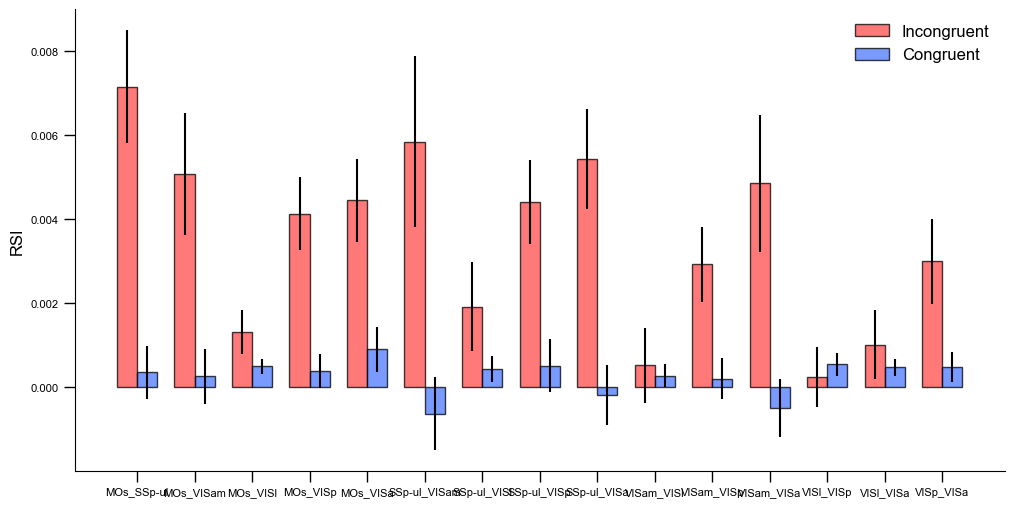

In [143]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    np.arange(rsi_inc_anima_stim.shape[1]) - 0.35 / 2,
    np.mean(rsi_inc_anima_stim, axis=0),
    yerr=np.std(rsi_inc_anima_stim, axis=0) / np.sqrt(rsi_inc_anima_stim.shape[0]),
    edgecolor="k",
    color="#FF4D4D",
    alpha=0.75,
    width=0.35,
    label="Incongruent",
)
ax.bar(
    np.arange(rsi_c_anima_stim.shape[1]) + 0.35 / 2,
    np.mean(rsi_c_anima_stim, axis=0),
    yerr=np.std(rsi_c_anima_stim, axis=0) / np.sqrt(rsi_c_anima_stim.shape[0]),
    edgecolor="k",
    color="#4D79FF",
    alpha=0.75,
    width=0.35,
    label="Congruent",
)
ax.set_xticks(np.arange(rsi_inc_anima_stim.shape[1]), names)
ax.set_ylabel("RSI")
ax.legend(loc="best", frameon=False)

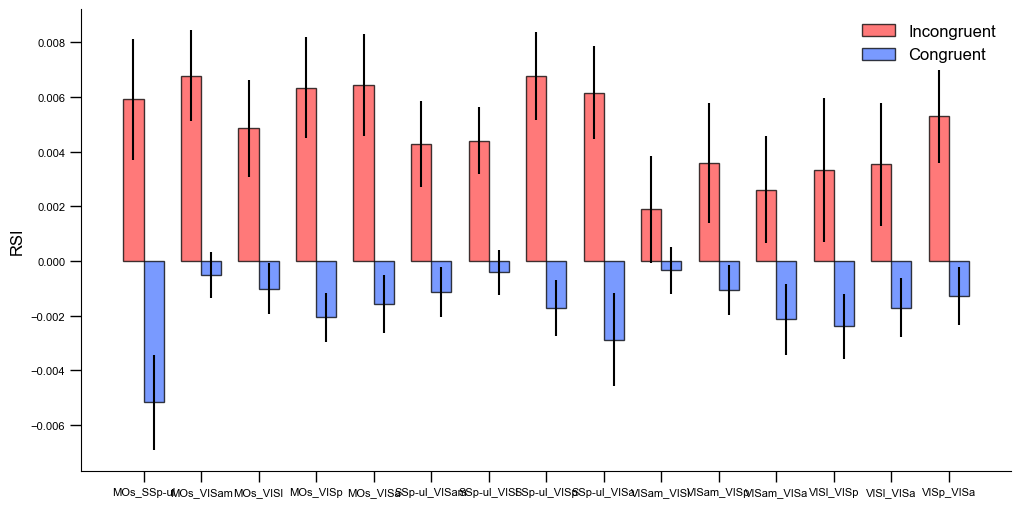

In [144]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    np.arange(rsi_inc_anima_choice.shape[1]) - 0.35 / 2,
    np.mean(rsi_inc_anima_choice, axis=0),
    yerr=np.std(rsi_inc_anima_choice, axis=0) / np.sqrt(rsi_inc_anima_choice.shape[0]),
    edgecolor="k",
    color="#FF4D4D",
    alpha=0.75,
    width=0.35,
    label="Incongruent",
)
ax.bar(
    np.arange(rsi_c_anima_choice.shape[1]) + 0.35 / 2,
    np.mean(rsi_c_anima_choice, axis=0),
    yerr=np.std(rsi_c_anima_choice, axis=0) / np.sqrt(rsi_c_anima_choice.shape[0]),
    edgecolor="k",
    color="#4D79FF",
    alpha=0.75,
    width=0.35,
    label="Congruent",
)
ax.set_xticks(np.arange(rsi_inc_anima_choice.shape[1]), names)
ax.set_ylabel("RSI")
ax.legend(loc="best", frameon=False)

In [100]:
# look at accuracies, and also per animal: yeah

In [118]:
def mean_accuracies_for_wifi_by_conditions(files):

    # we drop 'ff7a70f5-a2b6-4e7e-938e-e7208e0678c2'
    with open(files[0], "rb") as f:
        d = pkl.load(f)
    frames = list(d.keys())
    pairs = list(d[frames[0]].keys())
    regions = [re.findall(r"\['(.*?)'\]", p) for p in pairs]
    mean_accuracies = np.zeros((len(files), len(regions), 3, 4))

    for file_idx in range(len(files)):

        # if eid_found != -1:
        #     print(f"{files[file_idx]}")
        #     continue

        with open(files[file_idx], "rb") as f:
            d = pkl.load(f)

        frames = list(d.keys())
        pairs = list(d[frames[0]].keys())
        regions = [re.findall(r"\['(.*?)'\]", p) for p in pairs]
        for f_idx, frame in enumerate(frames):
            for k_idx, k in enumerate(d[frame].keys()):
                results = d[frame][k]["results"]
                mean_a_cong = []
                mean_b_cong = []

                mean_a_incong = []
                mean_b_incong = []

                for idx in range(len(results)):
                    mean_a_cong.append(results[idx]["balanced_acc_A_cong"])
                    mean_b_cong.append(results[idx]["balanced_acc_B_cong"])
                    mean_a_incong.append(results[idx]["balanced_acc_A_incong"])
                    mean_b_incong.append(results[idx]["balanced_acc_B_incong"])

                mean_accuracies[file_idx, k_idx, f_idx, 0] = np.mean(mean_a_cong)
                mean_accuracies[file_idx, k_idx, f_idx, 1] = np.mean(mean_a_incong)
                mean_accuracies[file_idx, k_idx, f_idx, 2] = np.mean(mean_b_cong)
                mean_accuracies[file_idx, k_idx, f_idx, 3] = np.mean(mean_b_incong)

                if np.mean(mean_a_cong) == 0:
                    print(f"{frame}, {k}, {files[file_idx]}")
    return mean_accuracies

In [38]:
# cannot do this. different sessions have different number of regions, and also different indices. maybe just use dicts


from collections import defaultdict


def mean_accuracies_flexible_regions(files, balanced=True):
    # data_store[region_name][frame_index] = list of [val1, val2, val3, val4] arrays
    data_store = defaultdict(lambda: defaultdict(list))

    num_frames_global = 0

    for file_path in files:
        try:
            with open(file_path, "rb") as f:
                d = pkl.load(f)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue

        frames = list(d.keys())
        if frames == []:
            continue
        num_frames_global = max(num_frames_global, len(frames))

        for f_idx, frame in enumerate(frames):

            for k in d[frame].keys():

                match = re.findall(r"\['(.*?)'\]", k)
                if not match:
                    continue  # Skip if regex fails
                match = sorted(match)
                region_name = match[0] + "_" + match[1]

                results = d[frame][k]["results"]
                if balanced:
                    mean_a_cong = [r["balanced_acc_A_cong"] for r in results]
                    mean_b_cong = [r["balanced_acc_B_cong"] for r in results]
                    mean_a_incong = [r["balanced_acc_A_incong"] for r in results]
                    mean_b_incong = [r["balanced_acc_B_incong"] for r in results]
                else:
                    mean_a_cong = [r["accuracy_A_cong"] for r in results]
                    mean_b_cong = [r["accuracy_B_cong"] for r in results]
                    mean_a_incong = [r["accuracy_A_incong"] for r in results]
                    mean_b_incong = [r["accuracy_B_incong"] for r in results]

                # Calculate the 4 means for this specific file
                current_file_means = np.array(
                    [
                        np.mean(mean_a_cong),
                        np.mean(mean_a_incong),
                        np.mean(mean_b_cong),
                        np.mean(mean_b_incong),
                    ]
                )
                data_store[region_name][f_idx].append(current_file_means)

                if np.mean(mean_a_cong) == 0:
                    print(f"Zero mean detected: {frame}, {k}, {file_path}")

    final_region_means = {}
    final_region_counts = {}

    for region_name, frame_data in data_store.items():

        region_matrix = np.full((num_frames_global, 4), np.nan)
        counts_matrix = np.zeros((num_frames_global,), dtype=int)

        for f_idx, values_list in frame_data.items():
            if values_list:
                region_matrix[f_idx] = np.mean(np.stack(values_list), axis=0)
                counts_matrix[f_idx] = len(values_list)

        final_region_means[region_name] = region_matrix
        final_region_counts[region_name] = counts_matrix
    return final_region_means, final_region_counts

In [39]:
mean_accuracies_by_condition_stim, counts_matrix = mean_accuracies_flexible_regions(
    files_stim, True
)

In [40]:
mean_accuracies_x = np.asarray(list(mean_accuracies_by_condition_stim.values()))
region_keys = list(mean_accuracies_by_condition_stim.keys())

Text(0, 0.5, 'Sessions')

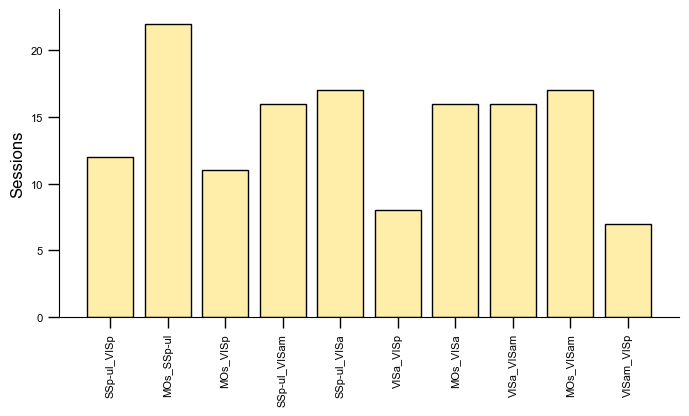

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))


ax.bar(
    np.arange(len(region_keys)),
    np.asarray(list(counts_matrix.values()))[:, 0],
    edgecolor="k",
    color="#ffeeaa",
)
ax.set_xticks(np.arange(len(region_keys)), region_keys, rotation=90)
ax.set_ylabel("Sessions")

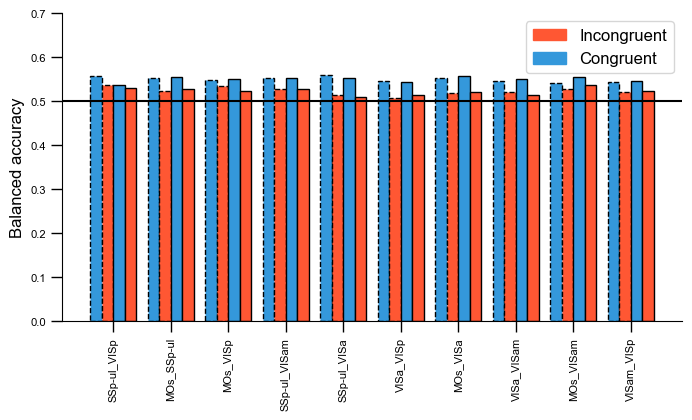

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = [
    "#3498DB",
    "#FF5733",
    "#3498DB",
    "#FF5733",
]
linestyle = ["--", "--", "-", "-"]
for idx in range(4):
    ax.bar(
        np.arange(len(region_keys)) + 0.2 * idx,
        mean_accuracies_x[:, 1, idx],
        width=0.2,
        color=colors[idx],
        edgecolor="k",
        linestyle=linestyle[idx],
    )

ax.set_xticks(np.arange(len(region_keys)) + 0.2 * (4 - 1) / 2, region_keys, rotation=90)
ax.set_ylim(0, 0.7)
ax.axhline(0.5)
ax.set_ylabel("Balanced accuracy")

red_patch = mpatches.Patch(color="#FF5733", label="Incongruent")
blue_patch = mpatches.Patch(color="#3498DB", label="Congruent")
plt.legend(handles=[red_patch, blue_patch])

Text(0, 0.5, 'Balanced accuracy')

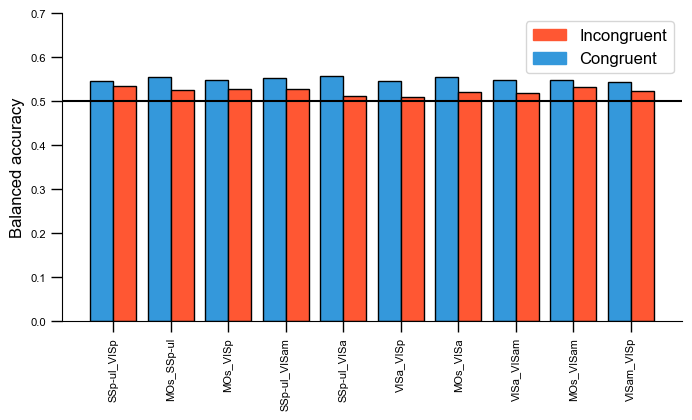

In [57]:
# [regiona-con, regiona-incon,regionb-con, regionb-incon]
average_con = np.mean(
    mean_accuracies_x[
        :,
        1,
        [0, 2],
    ],
    axis=-1,
)
average_incon = np.mean(
    mean_accuracies_x[
        :,
        1,
        [1, 3],
    ],
    axis=-1,
)
colors = [
    "#3498DB",
    "#FF5733",
]

fig, ax = plt.subplots(figsize=(8, 4))

averages = np.stack([average_con, average_incon])

for idx in range(2):
    ax.bar(
        np.arange(len(region_keys)) + 0.4 * idx,
        averages[idx, :],
        width=0.4,
        edgecolor="k",
        color=colors[idx],
    )


ax.set_xticks(np.arange(len(region_keys)) + 0.4 * (2 - 1) / 2, region_keys, rotation=90)
ax.set_ylim(0, 0.7)
ax.axhline(0.5)


red_patch = mpatches.Patch(color="#FF5733", label="Incongruent")
blue_patch = mpatches.Patch(color="#3498DB", label="Congruent")
plt.legend(handles=[red_patch, blue_patch])
ax.set_ylabel("Balanced accuracy")

In [115]:
mean_accuracies_by_condition_choice = mean_accuracies_for_wifi_by_conditions(files_choice_acc)

In [169]:
with open(files_choice[0], "rb") as f:
    x = pkl.load(f)

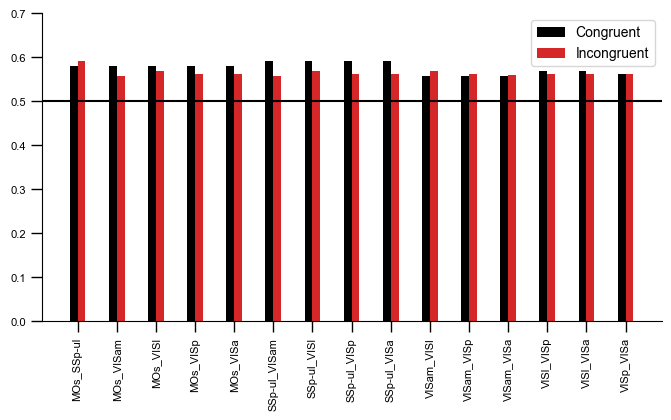

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))


for idx in range(2):
    ax.bar(
        np.arange(len(names)) + 0.2 * idx,
        np.mean(mean_accuracies_by_condition_choice, axis=0)[:, 2, idx],
        width=0.2,
    )

ax.set_xticks(np.arange(len(names)) + 0.2 / 2, names, rotation=90)
ax.set_ylim(0, 0.7)
plt.legend(["Congruent", "Incongruent"], fontsize="small")
ax.axhline(0.5)

Text(0, 0.5, 'Balanced accuracy')

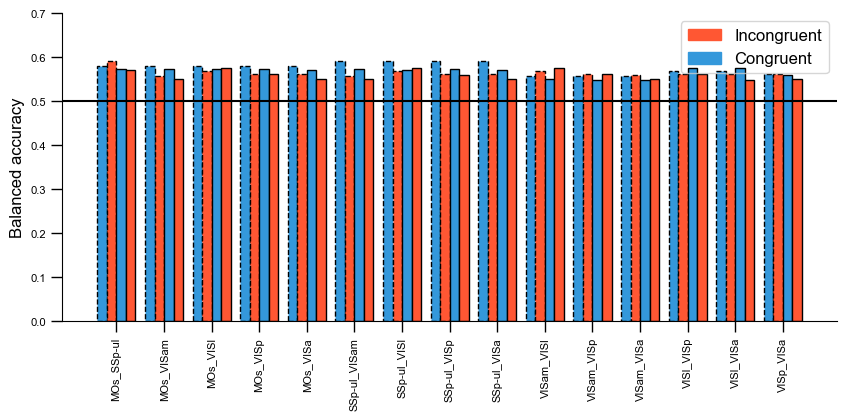

In [119]:
fig, ax = plt.subplots(figsize=(10, 4))


colors = [
    "#3498DB",
    "#FF5733",
    "#3498DB",
    "#FF5733",
]
linestyle = ["--", "--", "-", "-"]

for idx in range(4):
    ax.bar(
        np.arange(15) + 0.2 * idx,
        np.mean(mean_accuracies_by_condition_choice, axis=0)[:, 2, idx],
        width=0.2,
        color=colors[idx],
        edgecolor="k",
        linestyle=linestyle[idx],
    )

ax.set_xticks(np.arange(15) + 0.2 * (4 - 1) / 2, names, rotation=90)
ax.set_ylim(0, 0.7)
ax.axhline(0.5)

red_patch = mpatches.Patch(color="#FF5733", label="Incongruent")
blue_patch = mpatches.Patch(color="#3498DB", label="Congruent")
plt.legend(handles=[red_patch, blue_patch])
ax.set_ylabel("Balanced accuracy")

In [191]:
files_stim = np.sort(glob("../data/generated/quicktransfer/scaled/*.pkl"))

In [195]:
with open(files_stim[0], "rb") as f:
    d = pkl.load(f)

In [196]:
with open(files_stim[0], "rb") as f:
    d = pkl.load(f)
frames = list(d.keys())
pairs = list(d[frames[0]].keys())
regions = [re.findall(r"\['(.*?)'\]", p) for p in pairs]
names = [f"{r[0]}_{r[1]}" for r in regions]

In [197]:
mean_accuracies_by_condition_stim = mean_accuracies_for_wifi_by_conditions(files_stim)

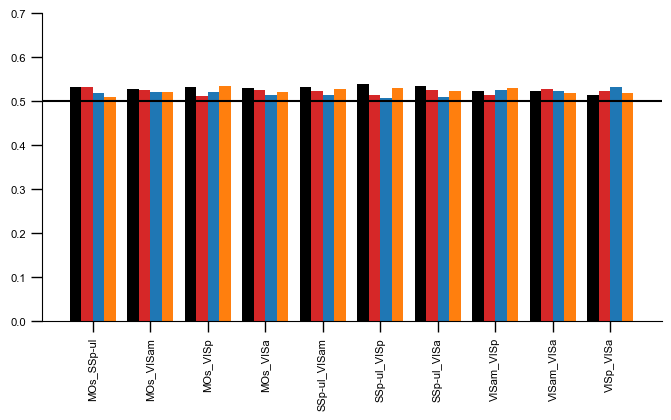

In [198]:
fig, ax = plt.subplots(figsize=(8, 4))

for idx in range(4):
    ax.bar(
        np.arange(len(names)) + 0.2 * idx,
        np.mean(mean_accuracies_by_condition_stim, axis=0)[:, 2, idx],
        width=0.2,
    )

ax.set_xticks(np.arange(len(names)) + 0.2 * (4 - 1) / 2, names, rotation=90)
ax.set_ylim(0, 0.7)
ax.axhline(0.5)

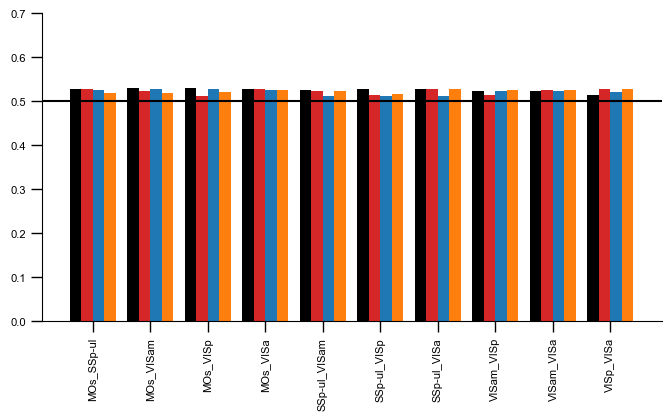

In [201]:
fig, ax = plt.subplots(figsize=(8, 4))

for idx in range(4):
    ax.bar(
        np.arange(len(names)) + 0.2 * idx,
        np.mean(mean_accuracies_by_condition_stim, axis=0)[:, 1, idx],
        width=0.2,
    )

ax.set_xticks(np.arange(len(names)) + 0.2 * (4 - 1) / 2, names, rotation=90)
ax.set_ylim(0, 0.7)
ax.axhline(0.5)

In [200]:
# load up the others

In [4]:
files_ephys_stim = np.sort(glob("../data/generated/ephys_pairs/stim/*.pkl"))
files_ephys_choice = np.sort(glob("../data/generated/ephys_pairs/choice/*.pkl"))

In [162]:
with open(files_ephys_stim[0], "rb") as f:
    x = pkl.load(f)

In [5]:
def deltas_array_ephys(region_data):
    balanced_accuracies_a = []
    balanced_accuracies_b = []
    null_accuracies_a = []
    null_accuracies_b = []

    for eid in region_data.keys():

        ba_a = [v["balanced_acc_A"] for v in region_data[eid]["decoding_results"]]
        ba_b = [v["balanced_acc_B"] for v in region_data[eid]["decoding_results"]]
        mean_a = np.mean(ba_a)
        mean_b = np.mean(ba_b)
        null_a = np.mean(region_data[eid]["null_results"]["acc_A"])
        null_b = np.mean(region_data[eid]["null_results"]["acc_B"])
        balanced_accuracies_a.append(mean_a)
        balanced_accuracies_b.append(mean_b)
        null_accuracies_a.append(null_a)
        null_accuracies_b.append(null_b)

    balanced_accuracies_a = np.asarray(balanced_accuracies_a)
    balanced_accuracies_b = np.asarray(balanced_accuracies_b)
    null_accuracies_a = np.asarray(null_accuracies_a)
    null_accuracies_b = np.asarray(null_accuracies_b)

    return balanced_accuracies_a, null_accuracies_a, balanced_accuracies_b, null_accuracies_b

In [6]:
delta_a, delta_b = [], []
animals = []
for files in files_ephys_stim:
    with open(files, "rb") as f:
        data = pkl.load(f)

    ba, bb, da, db = deltas_array_ephys(data)

    animals.append(len(ba))
    delta_a.append([ba, da])
    delta_b.append([bb, db])

In [190]:
def plot_real_null_ephys(delta_A_all, delta_B_all):

    n_regions = len(delta_A_all)

    offset = 0.25
    width = 0.35

    fig, ax = plt.subplots(figsize=(1.4 * n_regions, 5))

    for r in range(n_regions):
        # positions
        delta_A = delta_A_all[r]
        delta_B = delta_B_all[r]
        pos_A = r - offset
        pos_B = r + offset

        # boxplots
        ax.boxplot(
            delta_A,
            positions=[pos_A],
            widths=width,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(alpha=0.4),
            medianprops=dict(linewidth=2),
        )

        ax.boxplot(
            delta_B,
            positions=[pos_B],
            widths=width,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(alpha=0.4),
            medianprops=dict(linewidth=2),
        )

        # stripplots (jittered animals)
        jitter = 0.04
        ax.scatter(pos_A + jitter * np.random.randn(len(delta_A)), delta_A, alpha=0.8)

        ax.scatter(pos_B + jitter * np.random.randn(len(delta_B)), delta_B, alpha=0.8)

    # null line
    ax.axhline(0, linestyle="--", color="black", linewidth=1)

    # ticks and labels
    ax.set_xticks(range(n_regions))
    ax.set_ylabel("Real - Null decoding accuracy")
    ax.set_ylim(-0.1, 0.25)
    plt.tight_layout()
    plt.show()

Text(0.5, 1.0, 'Ephys data')

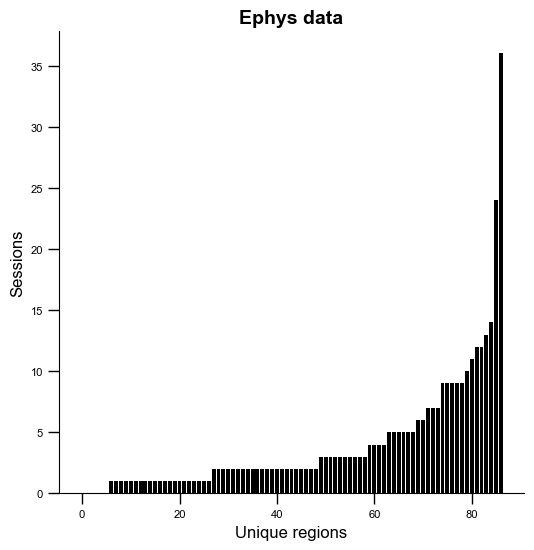

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.bar(np.arange(len(animals)), np.sort(animals))
ax.set_xlabel("Unique regions")
ax.set_ylabel("Sessions")
ax.set_title("Ephys data")

### only high contrast 
was useless

In [54]:
files_high_contrast = np.sort(glob("../data/generated/highcontrast/*.pkl"))

In [60]:
mean_accuracies_by_condition_high_contrast = mean_accuracies_for_wifi_by_conditions(
    files_high_contrast
)

In [67]:
with open(files_high_contrast[0], "rb") as f:
    d = pkl.load(f)
frames = list(d.keys())
pairs = list(d[frames[0]].keys())
regions = [re.findall(r"\['(.*?)'\]", p) for p in pairs]
names = [f"{r[0]}_{r[1]}" for r in regions]

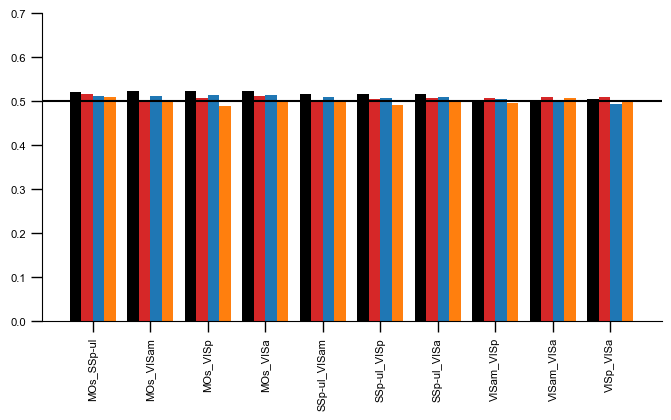

In [74]:
fig, ax = plt.subplots(figsize=(8, 4))

for idx in range(4):
    ax.bar(
        np.arange(10) + 0.2 * idx,
        np.mean(mean_accuracies_by_condition_high_contrast, axis=0)[:, 1, idx],
        width=0.2,
    )

ax.set_xticks(np.arange(10) + 0.2 * (4 - 1) / 2, names, rotation=90)
ax.set_ylim(0, 0.7)
ax.axhline(0.5)

### decomposition results

In [180]:
files_choice = np.sort(glob("../data/generated/wfi_decoders/choice/subsampled/*.pkl"))
files_stim = np.sort(glob("../data/generated/significant_pid_decoders/with_decomposition/*.pkl"))
files_stim_subsampled = np.sort(
    glob("../data/generated/significant_pid_decoders/subsampled/subsampled_decom/*.pkl")
)

In [270]:
with open(files_choice[0], "rb") as f:
    x = pkl.load(f)
pairs = list(x.keys())
regions = [re.findall(r"\['(.*?)'\]", p) for p in pairs]
names = [f"{r[0]}_{r[1]}" for r in regions]

In [65]:
from ibl_info.nur_decomposition_wifi import (
    collapse_region_recomputed,
    congregate_data_recomputed,
    pids_per_animal_recomputed,
)

In [284]:
(
    rsi_congruent_recomputed_choice,
    rsi_incongruent_recomputed_choice,
    rsi_all_recomputed_choice,
    rsi_subsampled_recomputed_choice,
    tvmi_choice,
) = congregate_data_recomputed(files_choice)

In [83]:
# compare subsampled vs incongruent

(49, 15, 4)

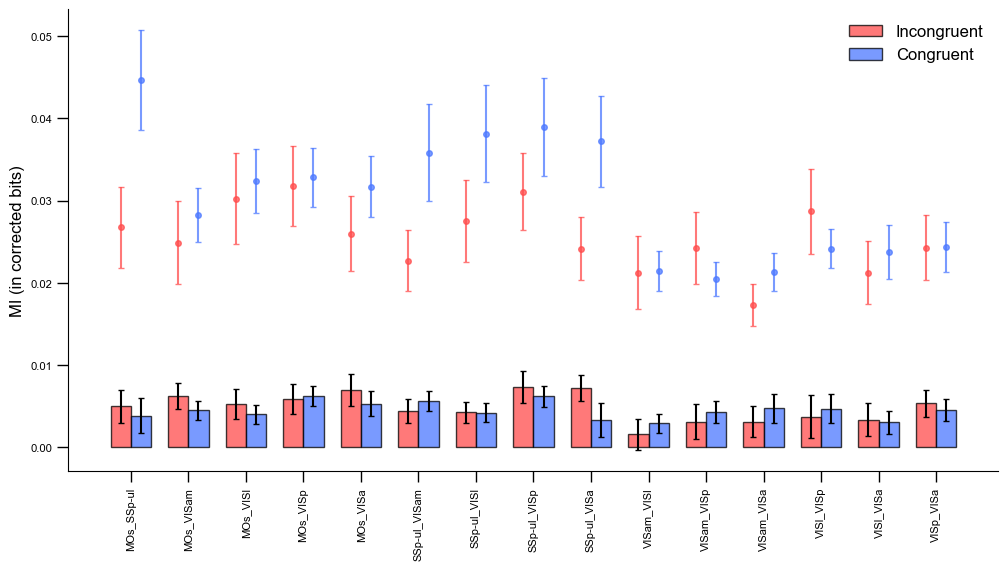

In [272]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    np.arange(rsi_incongruent_recomputed_choice.shape[1]) - 0.35 / 2,
    np.mean(rsi_incongruent_recomputed_choice, axis=0),
    yerr=np.std(rsi_incongruent_recomputed_choice, axis=0)
    / np.sqrt(rsi_incongruent_recomputed_choice.shape[0]),
    edgecolor="k",
    color="#FF4D4D",
    alpha=0.75,
    width=0.35,
    label="Incongruent",
    capsize=2,
)
ax.bar(
    np.arange(rsi_subsampled_recomputed_choice.shape[1]) + 0.35 / 2,
    np.mean(rsi_subsampled_recomputed_choice, axis=0),
    yerr=np.std(rsi_subsampled_recomputed_choice, axis=0)
    / np.sqrt(rsi_subsampled_recomputed_choice.shape[0]),
    edgecolor="k",
    color="#4D79FF",
    alpha=0.75,
    width=0.35,
    label="Congruent",
    capsize=2,
)
ax.set_xticks(np.arange(rsi_incongruent_recomputed_choice.shape[1]), names, rotation=90)
ax.set_ylabel("RSI")
ax.legend(loc="best", frameon=False)

ax.errorbar(
    np.arange(tvmi_choice.shape[1]) - 0.35 / 2,
    np.mean(tvmi_choice, axis=0)[:, 1],
    yerr=np.std(tvmi_choice, axis=0)[:, 1] / np.sqrt(tvmi_choice.shape[0]),
    # edgecolor="k",
    color="#FF4D4D",
    alpha=0.75,
    # width=0.35,
    fmt="o",
    capsize=2,
)
ax.errorbar(
    np.arange(tvmi_choice.shape[1]) + 0.35 / 2,
    np.mean(tvmi_choice, axis=0)[:, 3],
    yerr=np.std(tvmi_choice, axis=0)[:, 3] / np.sqrt(tvmi_choice.shape[0]),
    # edgecolor="k",
    color="#4D79FF",
    alpha=0.75,
    # width=0.35,
    fmt="o",
    capsize=2,
)
ax.set_xticks(np.arange(tvmi_choice.shape[1]), names, rotation=90)
ax.set_ylabel("MI (in corrected bits)")
ax.legend(loc="best", frameon=False)

In [268]:
# fig, ax = plt.subplots(figsize=(12, 6))
# ax.bar(
#     np.arange(tvmi_choice.shape[1]) - 0.35 / 2,
#     np.mean(tvmi_choice, axis=0)[:, 1],
#     yerr=np.std(tvmi_choice, axis=0)[:, 1] / np.sqrt(tvmi_choice.shape[0]),
#     edgecolor="k",
#     color="#FF4D4D",
#     alpha=0.75,
#     width=0.35,
#     label="Incongruent",
#     capsize=2,
# )
# ax.bar(
#     np.arange(tvmi_choice.shape[1]) + 0.35 / 2,
#     np.mean(tvmi_choice, axis=0)[:, 3],
#     yerr=np.std(tvmi_choice, axis=0)[:, 3] / np.sqrt(tvmi_choice.shape[0]),
#     edgecolor="k",
#     color="#4D79FF",
#     alpha=0.75,
#     width=0.35,
#     label="Congruent",
#     capsize=2,
# )
# ax.set_xticks(np.arange(tvmi_choice.shape[1]), names, rotation=90)
# ax.set_ylabel("MI (in corrected bits)")
# ax.legend(loc="best", frameon=False)

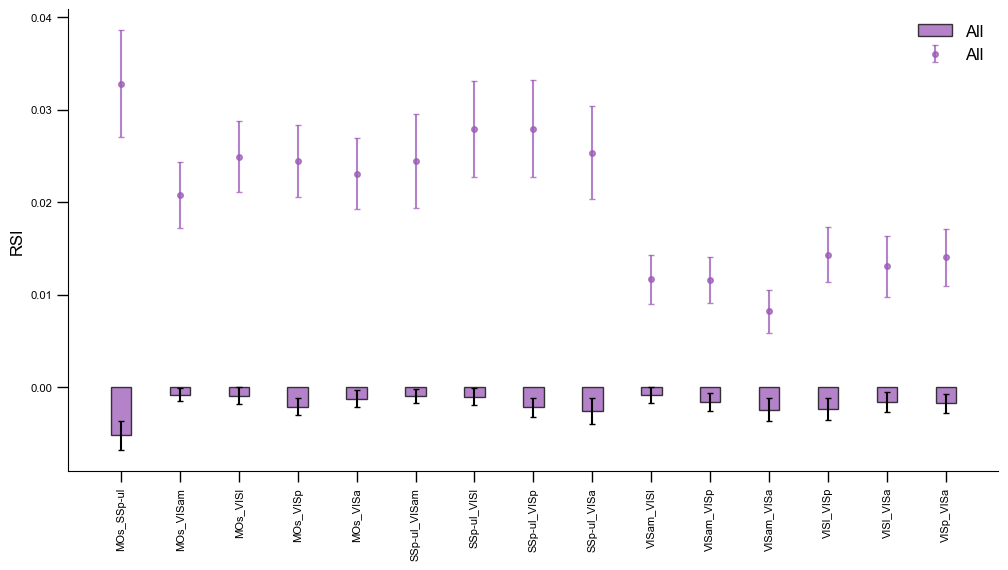

In [108]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    np.arange(rsi_all_recomputed_choice.shape[1]),
    np.mean(rsi_all_recomputed_choice, axis=0),
    yerr=np.std(rsi_all_recomputed_choice, axis=0) / np.sqrt(rsi_all_recomputed_choice.shape[0]),
    edgecolor="k",
    color="#9B59B6",
    alpha=0.75,
    width=0.35,
    label="All",
    capsize=2,
)
ax.errorbar(
    np.arange(tvmi_choice.shape[1]),
    np.mean(tvmi_choice, axis=0)[:, 2],
    yerr=np.std(tvmi_choice, axis=0)[:, 2] / np.sqrt(tvmi_choice.shape[0]),
    color="#9B59B6",
    alpha=0.75,
    label="All",
    capsize=2,
    fmt="o",
)
ax.set_xticks(np.arange(rsi_incongruent_recomputed_choice.shape[1]), names, rotation=90)
ax.set_ylabel("RSI")
ax.legend(loc="best", frameon=False)

In [181]:
# deal with the subsampled first

with open(files_stim_subsampled[1], "rb") as f:
    x = pkl.load(f)

In [183]:
x.keys()

dict_keys(["['SSp-ul']_['VISam']"])

In [ ]:
# files-stim needs to be organized a bit differently
# also should be resampled?


# how to organize, use the key structure

(20, 3, 7)

In [144]:
def convert_into_regionwise_dict(files):
    data_store = defaultdict(lambda: defaultdict(list))
    num_frames_global = 0
    for file_path in files:
        try:
            with open(file_path, "rb") as f:
                d = pkl.load(f)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue

        frames = list(d.keys())
        if frames == []:
            continue
        num_frames_global = max(num_frames_global, len(frames))

        for f_idx, frame in enumerate(frames):

            for k in d[frame].keys():

                match = re.findall(r"\['(.*?)'\]", k)
                if not match:
                    continue  # Skip if regex fails
                match = sorted(match)
                region_name = match[0] + "_" + match[1]

                info_results = d[frame][k]["information_results"]

                mean_info = np.mean(info_results, axis=0)

                data_store[region_name][f_idx].append(mean_info)

    return data_store

In [185]:
x["['SSp-ul']_['VISam']"].shape

(20, 4, 7)

In [190]:
def convert_into_regionwise_dict_subsampled(files):
    data_store = defaultdict(lambda: defaultdict(list))
    for file_path in files:
        try:
            with open(file_path, "rb") as f:
                d = pkl.load(f)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue

        regions = list(d.keys())
        if regions == []:
            continue

        for k in d.keys():

            match = re.findall(r"\['(.*?)'\]", k)
            if not match:
                continue  # Skip if regex fails
            match = sorted(match)
            region_name = match[0] + "_" + match[1]

            info_results = d[k]
            mean_info = np.mean(info_results, axis=0)

            data_store[region_name][0].append(mean_info)  # type: ignore
    return data_store

In [158]:
# now we compute averages for each region:
def compute_region_pid_dict(data_store, frame_idx):
    region_wise_pid = {}
    for k in data_store.keys():
        region_pid_array = np.asarray(data_store[k][frame_idx])
        rsi_array = region_pid_array[:, :, 2] - (
            region_pid_array[:, :, 0] + region_pid_array[:, :, 1]
        )
        # now over animals
        tvmi_array = region_pid_array[:, :, 2]
        animal_count = tvmi_array.shape[0]
        temp = {}
        temp["count"] = animal_count
        temp["tvmi"] = tvmi_array
        temp["rsi_array"] = rsi_array
        region_wise_pid[k] = temp
    return region_wise_pid

In [163]:
def compute_means_and_stds(region_wise_pid):
    mean_rsis = []
    mean_tvmis = []
    std_tvmis = []
    std_rsis = []

    for k in region_wise_pid.keys():
        mean_rsis.append(np.nanmean(region_wise_pid[k]["rsi_array"], axis=0))
        mean_tvmis.append(np.nanmean(region_wise_pid[k]["tvmi"], axis=0))

        std_rsis.append(
            np.nanstd(region_wise_pid[k]["rsi_array"], axis=0)
            / np.sqrt(region_wise_pid[k]["count"])
        )
        std_tvmis.append(
            np.nanstd(region_wise_pid[k]["tvmi"], axis=0) / np.sqrt(region_wise_pid[k]["count"])
        )

    mean_rsis = np.asarray(mean_rsis)
    mean_tvmis = np.asarray(mean_tvmis)
    std_tvmis = np.asarray(std_tvmis)
    std_rsis = np.asarray(std_rsis)

    return mean_rsis, mean_tvmis, std_tvmis, std_rsis

In [168]:
# now what
data_store = convert_into_regionwise_dict(files_stim)
region_wise_pid = compute_region_pid_dict(data_store, 1)  # frame on sein
mean_rsis, mean_tvmis, std_tvmis, std_rsis = compute_means_and_stds(region_wise_pid)

In [174]:
names = list(region_wise_pid.keys())

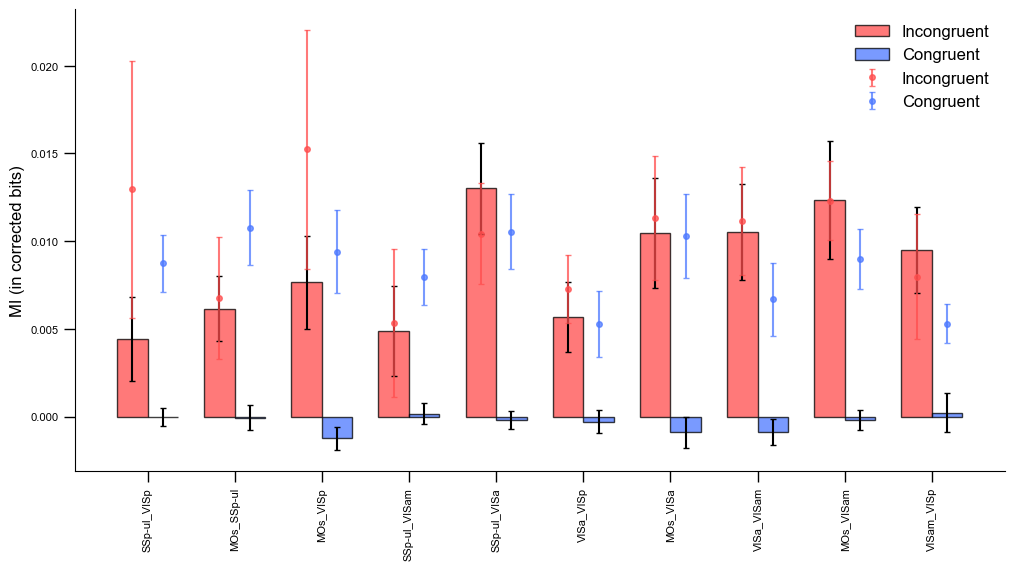

In [179]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    np.arange(mean_rsis.shape[0]) - 0.35 / 2,
    mean_rsis[:, 1],
    yerr=std_rsis[:, 1],
    edgecolor="k",
    color="#FF4D4D",
    alpha=0.75,
    width=0.35,
    label="Incongruent",
    capsize=2,
)
ax.bar(
    np.arange(mean_rsis.shape[0]) + 0.35 / 2,
    mean_rsis[:, 0],
    yerr=std_rsis[:, 0],
    edgecolor="k",
    color="#4D79FF",
    alpha=0.75,
    width=0.35,
    label="Congruent",
    capsize=2,
)
ax.set_xticks(np.arange(mean_rsis.shape[0]), names, rotation=90)
ax.set_ylabel("RSI")
ax.legend(loc="best", frameon=False)

ax.errorbar(
    np.arange(mean_tvmis.shape[0]) - 0.35 / 2,
    mean_tvmis[:, 1],
    yerr=std_tvmis[:, 1],
    color="#FF4D4D",
    alpha=0.75,
    fmt="o",
    label="Incongruent",
    capsize=2,
)
ax.errorbar(
    np.arange(mean_tvmis.shape[0]) + 0.35 / 2,
    mean_tvmis[:, 0],
    yerr=std_tvmis[:, 0],
    # edgecolor="k",
    color="#4D79FF",
    alpha=0.75,
    # width=0.35,
    fmt="o",
    label="Congruent",
    capsize=2,
)
ax.set_xticks(np.arange(mean_tvmis.shape[0]), names, rotation=90)
ax.set_ylabel("MI (in corrected bits)")
ax.legend(loc="best", frameon=False)

In [209]:
data_store_subsampled = convert_into_regionwise_dict_subsampled(files_stim_subsampled)
region_wise_pid_subsampled = compute_region_pid_dict(data_store_subsampled, 0)  # frame on
mean_rsis_subsampled, mean_tvmis_subsampled, std_tvmis_subsampled, std_rsis_subsampled = (
    compute_means_and_stds(region_wise_pid_subsampled)
)

In [245]:
region_wise_pid_subsampled.keys()

dict_keys(['SSp-ul_VISp', 'MOs_SSp-ul', 'MOs_VISp', 'SSp-ul_VISam', 'SSp-ul_VISa', 'VISa_VISp', 'MOs_VISa', 'VISa_VISam', 'MOs_VISam', 'VISam_VISp'])

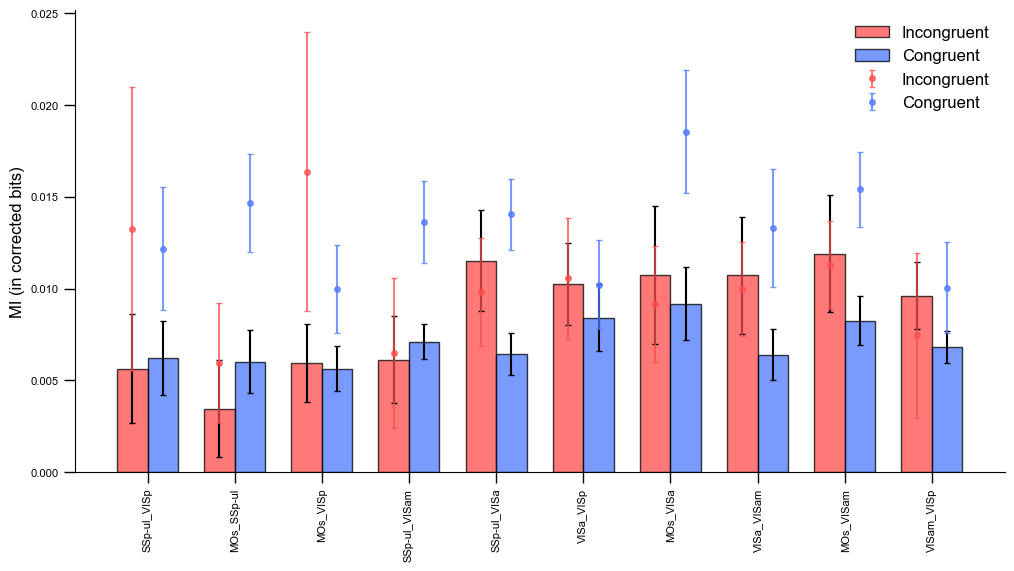

In [198]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    np.arange(mean_rsis_subsampled.shape[0]) - 0.35 / 2,
    mean_rsis_subsampled[:, 1],
    yerr=std_rsis_subsampled[:, 1],
    edgecolor="k",
    color="#FF4D4D",
    alpha=0.75,
    width=0.35,
    label="Incongruent",
    capsize=2,
)
ax.bar(
    np.arange(mean_rsis_subsampled.shape[0]) + 0.35 / 2,
    mean_rsis_subsampled[:, 3],
    yerr=std_rsis_subsampled[:, 3],
    edgecolor="k",
    color="#4D79FF",
    alpha=0.75,
    width=0.35,
    label="Congruent",
    capsize=2,
)
ax.set_xticks(np.arange(mean_rsis_subsampled.shape[0]), names, rotation=90)
ax.set_ylabel("RSI")
ax.legend(loc="best", frameon=False)

ax.errorbar(
    np.arange(mean_tvmis_subsampled.shape[0]) - 0.35 / 2,
    mean_tvmis_subsampled[:, 1],
    yerr=std_tvmis_subsampled[:, 1],
    color="#FF4D4D",
    alpha=0.75,
    fmt="o",
    label="Incongruent",
    capsize=2,
)
ax.errorbar(
    np.arange(mean_tvmis_subsampled.shape[0]) + 0.35 / 2,
    mean_tvmis_subsampled[:, 3],
    yerr=std_tvmis_subsampled[:, 3],
    # edgecolor="k",
    color="#4D79FF",
    alpha=0.75,
    # width=0.35,
    fmt="o",
    label="Congruent",
    capsize=2,
)
ax.set_xticks(np.arange(mean_tvmis_subsampled.shape[0]), names, rotation=90)
ax.set_ylabel("MI (in corrected bits)")
ax.legend(loc="best", frameon=False)

Text(0.5, 1.0, 'Stimulus')

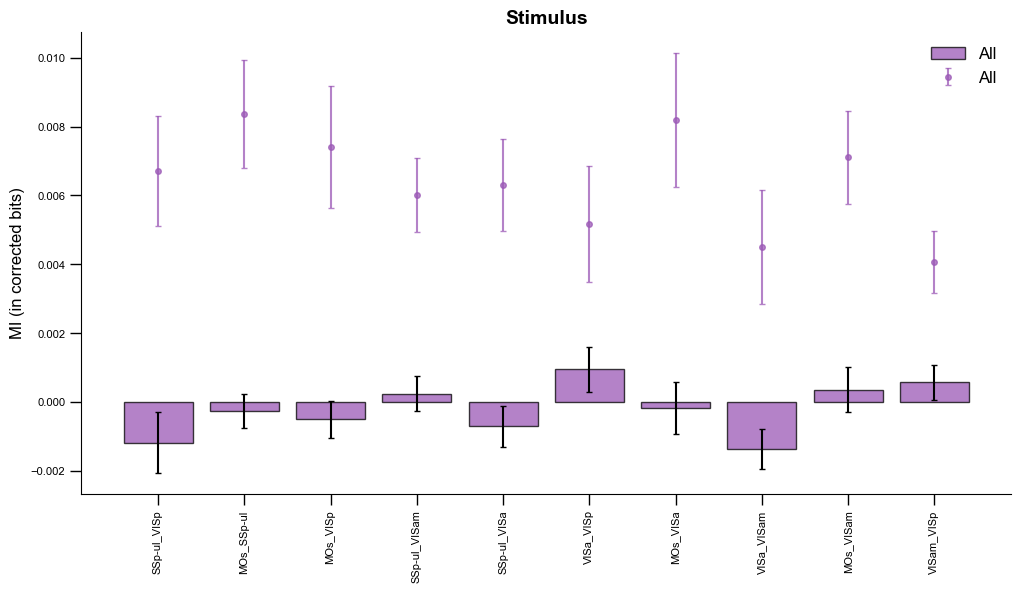

In [202]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    np.arange(mean_rsis_subsampled.shape[0]),
    mean_rsis_subsampled[:, 2],
    yerr=std_rsis_subsampled[:, 2],
    edgecolor="k",
    color="#9B59B6",
    alpha=0.75,
    label="All",
    capsize=2,
)
ax.errorbar(
    np.arange(mean_tvmis_subsampled.shape[0]),
    mean_tvmis_subsampled[:, 2],
    yerr=std_tvmis_subsampled[:, 2],
    color="#9B59B6",
    alpha=0.75,
    fmt="o",
    label="All",
    capsize=2,
)
ax.set_xticks(np.arange(mean_tvmis_subsampled.shape[0]), names, rotation=90)
ax.set_ylabel("MI (in corrected bits)")
ax.legend(loc="best", frameon=False)

ax.set_title("Stimulus")

Text(0.5, 1.0, 'Choice')

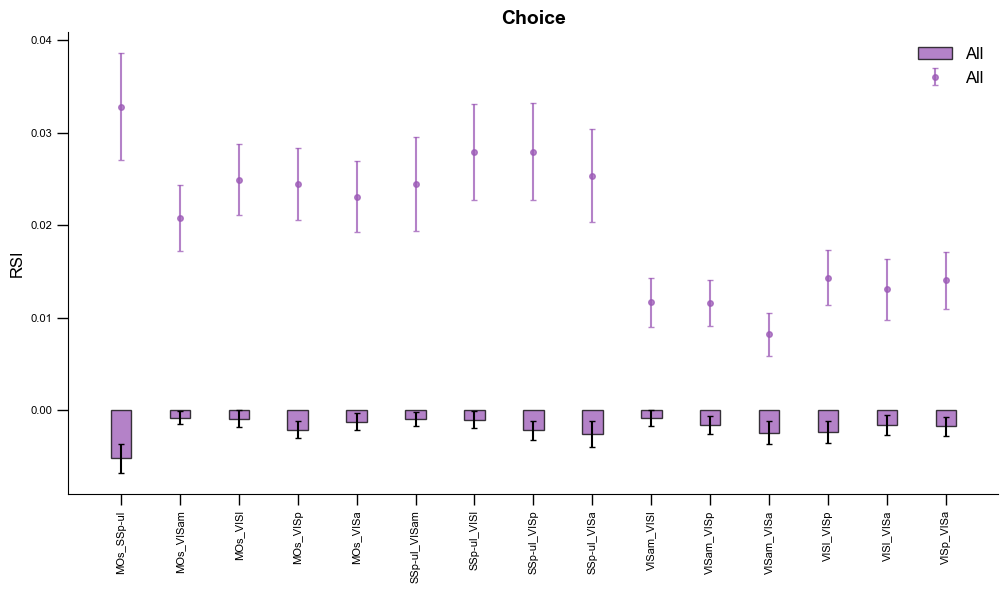

In [221]:
fig, ax = plt.subplots(figsize=(12, 6))
with open(files_choice[0], "rb") as f:
    xtemp = pkl.load(f)
pairs = list(xtemp.keys())
regions = [re.findall(r"\['(.*?)'\]", p) for p in pairs]
names_choice = [f"{r[0]}_{r[1]}" for r in regions]
ax.bar(
    np.arange(rsi_all_recomputed_choice.shape[1]),
    np.mean(rsi_all_recomputed_choice, axis=0),
    yerr=np.std(rsi_all_recomputed_choice, axis=0) / np.sqrt(rsi_all_recomputed_choice.shape[0]),
    edgecolor="k",
    color="#9B59B6",
    alpha=0.75,
    width=0.35,
    label="All",
    capsize=2,
)
ax.errorbar(
    np.arange(tvmi_choice.shape[1]),
    np.mean(tvmi_choice, axis=0)[:, 2],
    yerr=np.std(tvmi_choice, axis=0)[:, 2] / np.sqrt(tvmi_choice.shape[0]),
    color="#9B59B6",
    alpha=0.75,
    label="All",
    capsize=2,
    fmt="o",
)
ax.set_xticks(np.arange(rsi_incongruent_recomputed_choice.shape[1]), names, rotation=90)
ax.set_ylabel("RSI")
ax.legend(loc="best", frameon=False)
ax.set_title("Choice")

In [288]:
# organize this
names_stim = region_wise_pid_subsampled.keys()

In [225]:
rsi_all_choice_means = np.mean(rsi_all_recomputed_choice, axis=0)
rsi_all_choice_stds = np.std(rsi_all_recomputed_choice, axis=0) / np.sqrt(
    rsi_all_recomputed_choice.shape[0]
)
tvmi_all_choice_means = np.mean(tvmi_choice, axis=0)[:, 2]
tvmi_all_choice_stds = np.std(tvmi_choice, axis=0)[:, 2] / np.sqrt(tvmi_choice.shape[0])

In [228]:
choice_comparator_rsi = []
choice_comparator_tvmi = []
for names in names_stim:

    for idx in range(len(names_choice)):
        match = names_choice[idx].rsplit("_")
        match = sorted(match)
        region_name = match[0] + "_" + match[1]
        if region_name == names:
            choice_comparator_rsi.append([rsi_all_choice_means[idx], rsi_all_choice_stds[idx]])
            choice_comparator_tvmi.append([tvmi_all_choice_means[idx], tvmi_all_choice_stds[idx]])

In [229]:
choice_comparator_tvmi = np.asarray(choice_comparator_tvmi)
choice_comparator_rsi = np.asarray(choice_comparator_rsi)

Text(0.5, 1.0, 'Stimulus/Choice from same regions')

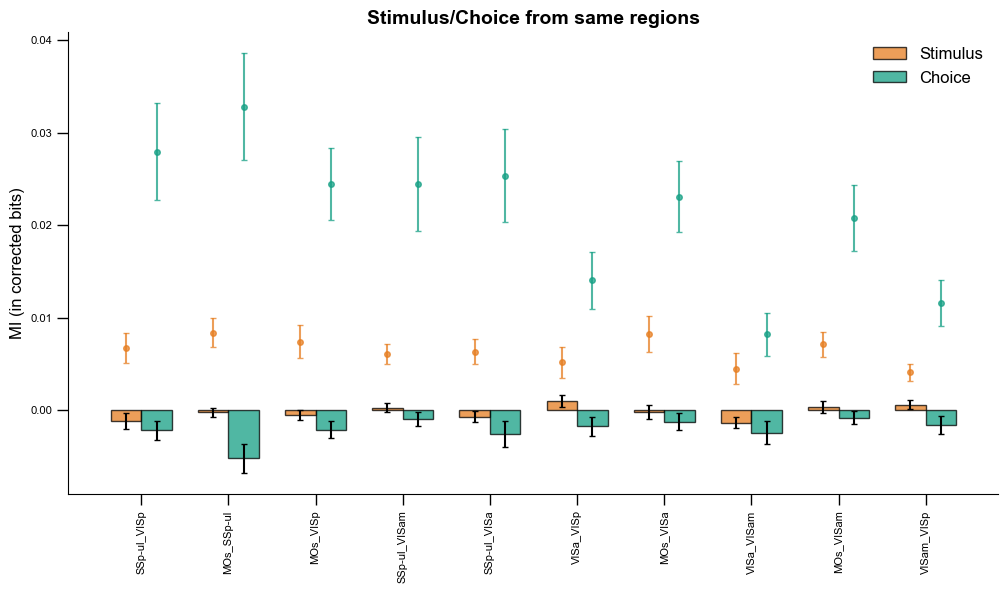

In [243]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    np.arange(mean_rsis_subsampled.shape[0]) - 0.35 / 2,
    mean_rsis_subsampled[:, 2],
    yerr=std_rsis_subsampled[:, 2],
    edgecolor="k",
    color="#E67E22",
    alpha=0.75,
    label="Stimulus",
    width=0.35,
    capsize=2,
)
ax.errorbar(
    np.arange(mean_tvmis_subsampled.shape[0]) - 0.35 / 2,
    mean_tvmis_subsampled[:, 2],
    yerr=std_tvmis_subsampled[:, 2],
    color="#E67E22",
    alpha=0.75,
    fmt="o",
    capsize=2,
)
ax.bar(
    np.arange(choice_comparator_rsi.shape[0]) + 0.35 / 2,
    choice_comparator_rsi[:, 0],
    yerr=choice_comparator_rsi[:, 1],
    edgecolor="k",
    color="#16A085",
    alpha=0.75,
    label="Choice",
    width=0.35,
    capsize=2,
)
ax.errorbar(
    np.arange(choice_comparator_rsi.shape[0]) + 0.35 / 2,
    choice_comparator_tvmi[:, 0],
    yerr=choice_comparator_tvmi[:, 1],
    color="#16A085",
    alpha=0.75,
    fmt="o",
    capsize=2,
)
ax.set_xticks(np.arange(mean_tvmis_subsampled.shape[0]), names_stim, rotation=90)
ax.set_ylabel("MI (in corrected bits)")
ax.legend(loc="best", frameon=False)

ax.set_title("Stimulus/Choice from same regions")

In [251]:
subsampled_stimulus_scores = [v.get("rsi_array") for v in region_wise_pid_subsampled.values()]

In [266]:
subsampled_stimulus_scores_tvmi = [v.get("tvmi") for v in region_wise_pid_subsampled.values()]

In [305]:
from scipy.stats import wilcoxon, mannwhitneyu
from statsmodels.stats.multitest import multipletests

In [ ]:


raw_p_values = []
n_regions = len(rsi_incongruent_recomputed_choice.T)
# 1. Run Wilcoxon for each region independently
for i in range(n_regions):
    A = tvmi_choice[:, i, 1]
    B = tvmi_choice[:, i, 3]
    # 'alternative' can be 'two-sided', 'greater', or 'less' depending on your hypothesis
    stat, p = wilcoxon(A, B, alternative="two-sided")
    raw_p_values.append(p)

# 2. Apply False Discovery Rate (FDR) Correction
# This adjusts the p-values to control the rate of false positives
reject, pvals_corrected, _, _ = multipletests(raw_p_values, alpha=0.05, method="fdr_bh")

# 3. Identify Significant Regions
significant_indices = np.where(reject)[0]

print(f"Total Regions: {n_regions}")
print(f"Significant Regions (after FDR correction): {len(significant_indices)}")
print(f"Indices: {significant_indices}")

# Optional: Print the corrected p-values for the significant ones
for idx in significant_indices:
    print(f"Region {names[idx]}: p_raw={raw_p_values[idx]:.4f}, p_corr={pvals_corrected[idx]:.4f}")

Total Regions: 15
Significant Regions (after FDR correction): 3
Indices: [0 5 6]
Region MOs_SSp-ul: p_raw=0.0000, p_corr=0.0002
Region SSp-ul_VISam: p_raw=0.0016, p_corr=0.0113
Region SSp-ul_VISl: p_raw=0.0023, p_corr=0.0113


In [291]:
choice_comparator_rsi = []
for names in names_stim:

    for idx in range(len(names_choice)):
        match = names_choice[idx].rsplit("_")
        match = sorted(match)
        region_name = match[0] + "_" + match[1]
        if region_name == names:
            choice_comparator_rsi.append([rsi_all_recomputed_choice[:, idx]])

In [294]:
choice_comparator_rsi = np.asarray(choice_comparator_rsi).reshape(-1, 49)

In [299]:
subsampled_stimulus_scores = [v.get("rsi_array") for v in region_wise_pid_subsampled.values()]

In [ ]:
# stim and choice

region_wise_pid_subsampled["MOs_SSp-ul"]["rsi_array"]

(22, 4)

In [303]:
subsampled_stimulus_scores[0].shape, choice_comparator_rsi.shape

((12, 4), (10, 49))

[np.float64(0.7234992151895638),
 np.float64(0.08063844503044697),
 np.float64(0.7598567272274205),
 np.float64(0.9090676234460243),
 np.float64(0.8373488941939096),
 np.float64(0.20650812292380138),
 np.float64(0.83711399787825),
 np.float64(0.06427354288896373),
 np.float64(0.13860926672706375),
 np.float64(0.3804368451871226)]